libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


image augmentation (cnn)

In [2]:
cnn_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

cnn_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

cnn dataset loading

In [3]:
train_dir = r"C:\Users\HP\Documents\project\capped_dataset\train"
val_dir = r"C:\Users\HP\Documents\project\capped_dataset\val"

cnn_train_dataset = datasets.ImageFolder(train_dir, transform=cnn_train_transforms)
cnn_val_dataset = datasets.ImageFolder(val_dir, transform=cnn_val_transforms)

num_classes = len(cnn_train_dataset.classes)
print("Number of classes:", num_classes)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Number of classes: 38


mlp preprocessing pipeline

In [4]:
mlp_transforms = transforms.Compose([
    transforms.Resize((64, 64)),   # 👈 reduced for MLP
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

mlp dataset loading

In [5]:
mlp_train_dataset = datasets.ImageFolder(train_dir, transform=mlp_transforms)
mlp_val_dataset = datasets.ImageFolder(val_dir, transform=mlp_transforms)

mlp_train_loader = DataLoader(
    mlp_train_dataset,
    batch_size=32,
    shuffle=True
)

mlp_val_loader = DataLoader(
    mlp_val_dataset,
    batch_size=32,
    shuffle=False
)

mlp architecture

In [6]:
class MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64*64*3, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(self.flatten(x))

mlp_model = MLP(num_classes).to(device)

cnn architecture

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(256*14*14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

cnn_model = CNN(num_classes).to(device)

training loop

In [8]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_acc.append(train_accuracy)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_acc.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_accuracy:.2f}% "
              f"Val Acc: {val_accuracy:.2f}%")

    return train_acc, val_acc

execute mlp training

In [9]:
print("Training MLP...")
mlp_train_acc, mlp_val_acc = train_model(
    mlp_model,
    mlp_train_loader,
    mlp_val_loader,
    epochs=5
)

Training MLP...
Epoch [1/5] Train Acc: 56.31% Val Acc: 64.74%
Epoch [2/5] Train Acc: 68.89% Val Acc: 68.41%
Epoch [3/5] Train Acc: 72.88% Val Acc: 72.55%
Epoch [4/5] Train Acc: 75.58% Val Acc: 72.86%
Epoch [5/5] Train Acc: 77.80% Val Acc: 70.64%


execute cnn training

In [10]:
print("\nTraining CNN...")
cnn_train_acc, cnn_val_acc = train_model(
    cnn_model,
    cnn_train_loader,
    cnn_val_loader,
    epochs=3
)


Training CNN...


c:\Users\HP\Documents\project\plantdoc\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/3] Train Acc: 49.17% Val Acc: 79.23%
Epoch [2/3] Train Acc: 73.24% Val Acc: 90.26%
Epoch [3/3] Train Acc: 79.69% Val Acc: 89.72%


remaining epoch

In [15]:
print("\nContinuing CNN Training...")
# Run the 2 extra epochs
cnn_train_acc_more, cnn_val_acc_more = train_model(
    cnn_model,
    cnn_train_loader,
    cnn_val_loader,
    epochs=2
)

# GLUE the new results to the old ones
cnn_train_acc.extend(cnn_train_acc_more)
cnn_val_acc.extend(cnn_val_acc_more)

print(f"Done! You now have {len(cnn_train_acc)} epochs of data.")


Continuing CNN Training...
Epoch [1/2] Train Acc: 84.19% Val Acc: 93.48%
Epoch [2/2] Train Acc: 86.74% Val Acc: 95.31%
Done! You now have 5 epochs of data.


accuracy graph

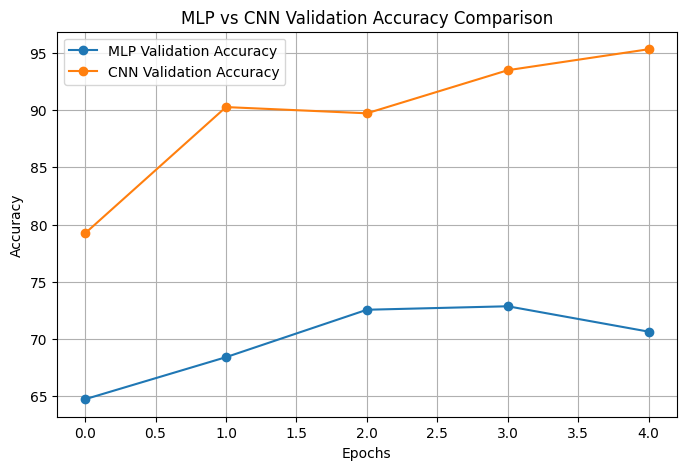

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(mlp_val_acc, marker='o', label="MLP Validation Accuracy")
plt.plot(cnn_val_acc, marker='o', label="CNN Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("MLP vs CNN Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

visulalize

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ---------- Function to visualize predictions ----------
def test_model_on_samples(model, dataset, class_names, num_samples=2, device=device):
    """
    Display random images from the validation dataset with predicted and true labels.
    Green title = correct prediction, Red title = wrong.
    """
    model.eval()  # Set model to evaluation mode
    
    # Pick random sample indices
    sample_indices = random.sample(range(len(dataset)), num_samples)
    
    # Create subplots
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            image, true_label = dataset[idx]
            true_class = class_names[true_label]
            
            # Prepare image for model
            image_batch = image.unsqueeze(0).to(device)
            
            # Get prediction
            output = model(image_batch)
            probs = torch.softmax(output, dim=1)
            pred_label = torch.argmax(probs, dim=1).item()
            pred_class = class_names[pred_label]
            confidence = probs[0, pred_label].item() * 100
            
            # Denormalize for display
            img_display = image.permute(1,2,0).cpu().numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)
            
            # Plot
            axes[i].imshow(img_display)
            axes[i].axis('off')
            axes[i].set_title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%",
                              color='green' if pred_class==true_class else 'red', fontsize=12)
    
    plt.tight_layout()
    plt.show()

using mlp

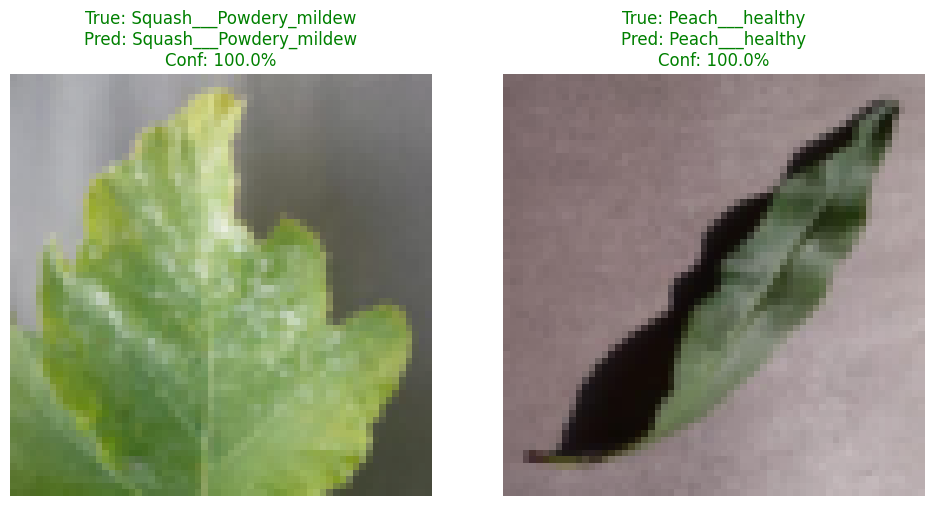

In [13]:
test_model_on_samples(
    model=mlp_model,
    dataset=mlp_val_dataset,
    class_names=mlp_train_dataset.classes,
    num_samples=2,
    device=device
)

using cnn

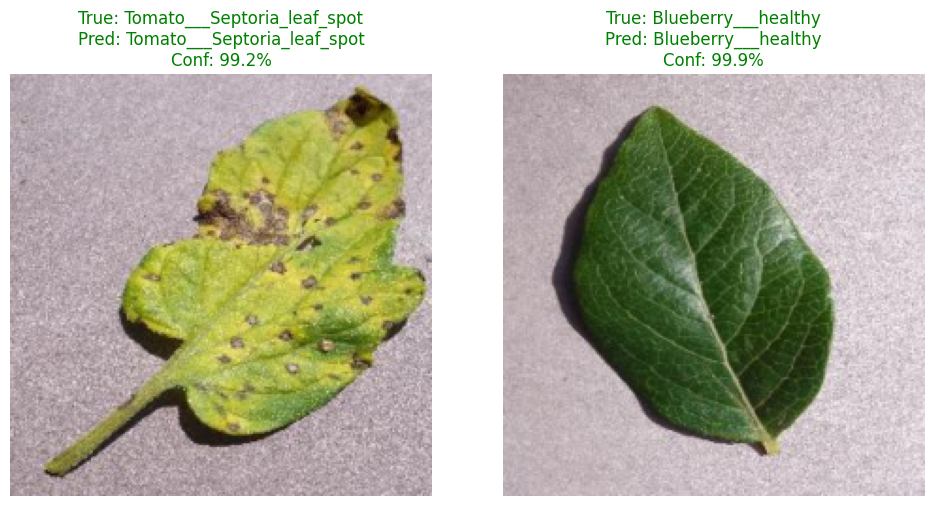

In [14]:
test_model_on_samples(
    model=cnn_model,
    dataset=cnn_val_dataset,
    class_names=cnn_train_dataset.classes,
    num_samples=2,   # number of random images to visualize
    device=device
)

model save

In [ ]:
# 1. Define the filename
model_save_path = 'best_simplecnn_plant_disease.pth'

# 2. Grab the names from your dataset
class_names = cnn_train_dataset.classes

# 3. THE SAVE
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'class_names': class_names,
    'num_classes': len(class_names),
    'input_size': (3, 224, 224)
}, model_save_path)

print(f" Success! '{model_save_path}' is saved.")

 Success! 'best_simplecnn_plant_disease.pth' is saved. You can now safely shutdown.
